<h1 style="text-align:center">Exploratory Data Analysis (EDA)</h1>

## 1. Environment Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

## 2. Project Paths

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATASET_PATH = PROJECT_ROOT / "data" / "raw"
MANIFEST_PATH = PROJECT_ROOT / "data" / "dataset_manifest.csv"

## 3. Load Dataset Manifest

In [3]:
df = pd.read_csv(MANIFEST_PATH)

df.head()

,image_path,label
0,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,glioma
1,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,glioma
2,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,glioma
3,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,glioma
4,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,glioma


## 4. Dataset Overview

In [4]:
print("Total Samples:", len(df))
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Total Samples: 5712

Columns: ['image_path', 'label']

Missing Values:
 image_path    0
label         0
dtype: int64


## 5. Class Mapping (Tumor Types)

In [5]:
classes = sorted(df["label"].unique())
classes

['glioma', 'meningioma', 'no_tumor', 'pituitary']

## 6. Class Distribution (Core Medical Imbalance Check)

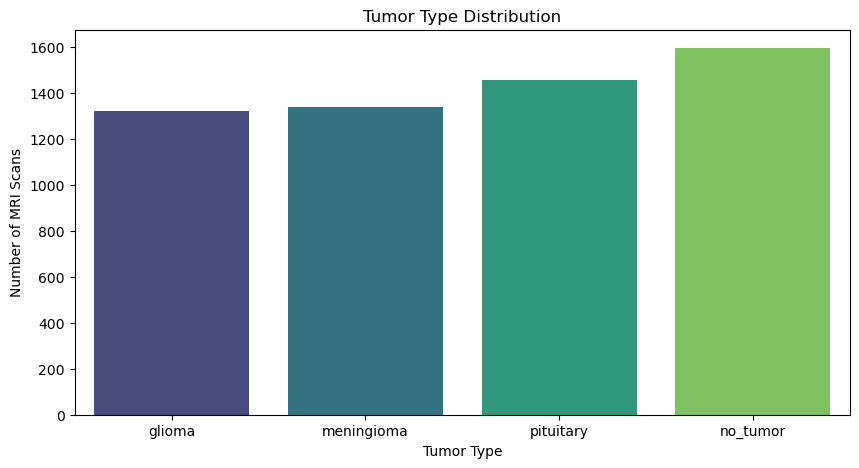

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="label",
    hue="label",
    palette="viridis",
    legend=False
)

plt.title("Tumor Type Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of MRI Scans")
plt.xticks(rotation=0)

plt.show()

## 7. Percentage Distribution

In [7]:
(df["label"].value_counts(normalize=True) * 100).round(2)

label
no_tumor      27.92
pituitary     25.51
meningioma    23.44
glioma        23.13
Name: proportion, dtype: float64

## 8. Random Sample Visualization (Per Class)

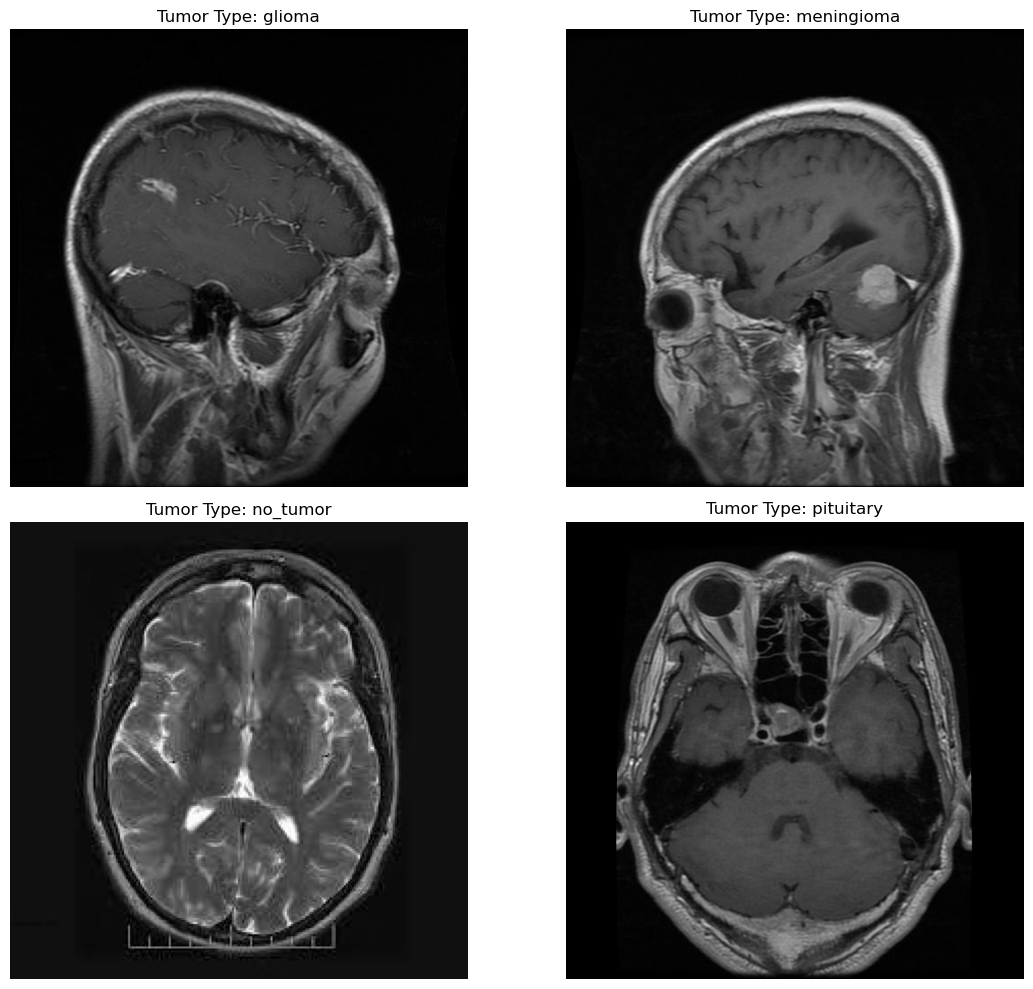

In [12]:
plt.figure(figsize=(12,10))

for i, cls in enumerate(classes):
    sample_path = df[df["label"] == cls]["image_path"].sample(1).values[0]
    img = Image.open(sample_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Tumor Type: {cls}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Grid Visualization (Multi-sample per Class)

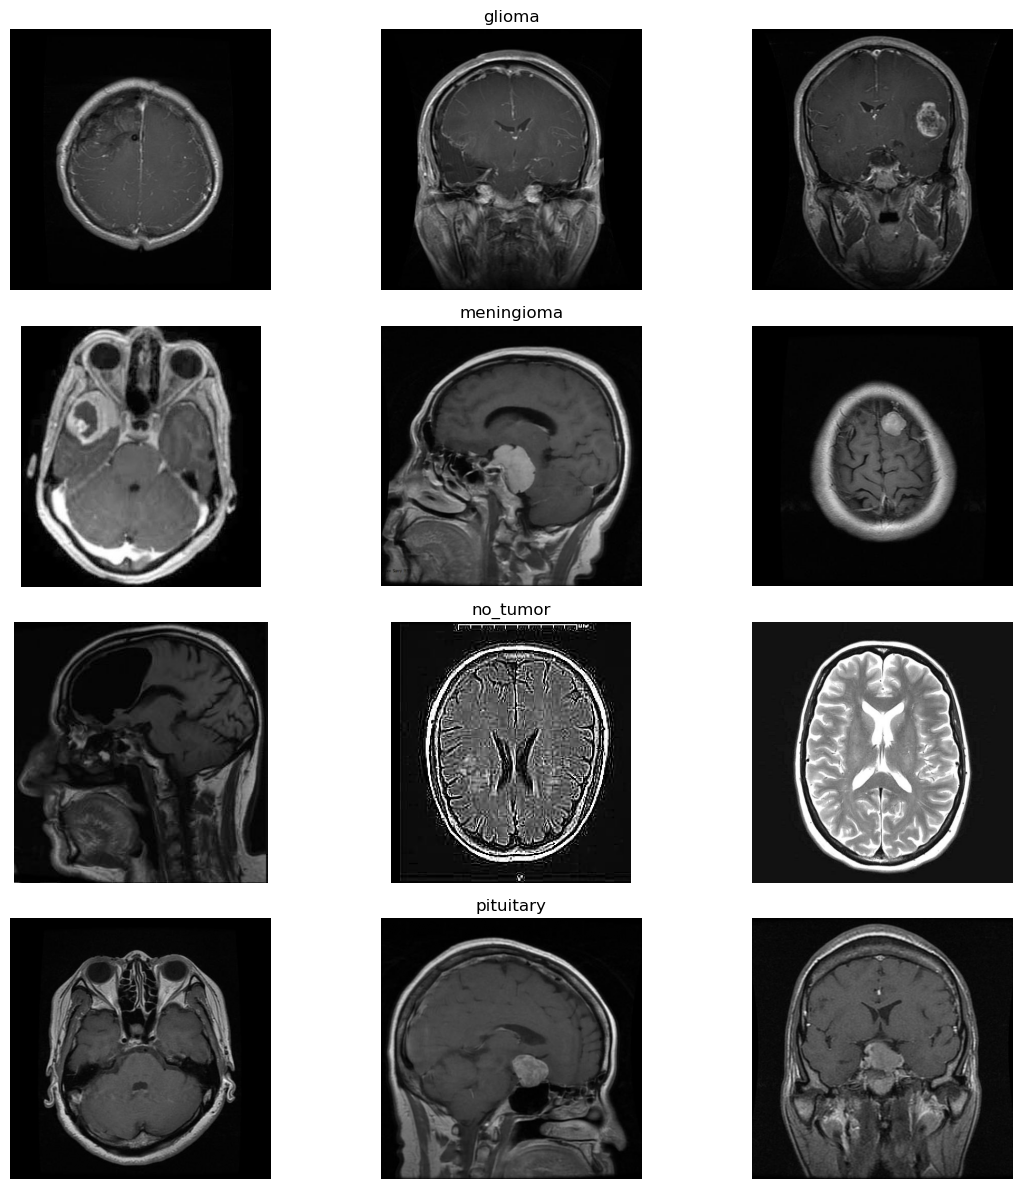

In [13]:
fig, axes = plt.subplots(len(classes), 3, figsize=(12,12))

for i, cls in enumerate(classes):
    samples = df[df["label"] == cls]["image_path"].sample(3).values

    for j, path in enumerate(samples):
        img = Image.open(path)

        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")

        if j == 1:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()

## 10. Image Dimension Analysis

In [14]:
shapes = []

sample_df = df.sample(200, random_state=42)

for path in sample_df["image_path"]:
    img = Image.open(path)
    shapes.append(np.array(img).shape)

pd.Series(shapes).value_counts()

(512, 512, 3)    131
(512, 512)        23
(225, 225, 3)      5
(444, 468, 3)      3
(198, 150, 3)      2
(630, 630, 3)      2
(168, 300, 3)      2
(442, 442, 3)      2
(832, 825, 3)      1
(540, 504, 3)      1
(217, 232, 3)      1
(496, 411, 3)      1
(396, 402, 3)      1
(249, 206, 3)      1
(443, 354, 3)      1
(251, 201, 3)      1
(513, 502, 3)      1
(236, 214, 3)      1
(490, 410, 3)      1
(257, 236, 3)      1
(252, 222, 3)      1
(207, 207, 3)      1
(261, 235, 3)      1
(250, 201, 3)      1
(218, 234, 3)      1
(221, 228, 3)      1
(248, 208, 3)      1
(417, 428, 3)      1
(270, 250, 3)      1
(630, 630)         1
(214, 235, 3)      1
(442, 400, 3)      1
(262, 227, 3)      1
(259, 194, 3)      1
(208, 233, 3)      1
(242, 208, 3)      1
(326, 276, 3)      1
(442, 441, 3)      1
Name: count, dtype: int64

## 11. Pixel Intensity Distribution (Per Tumor Type)

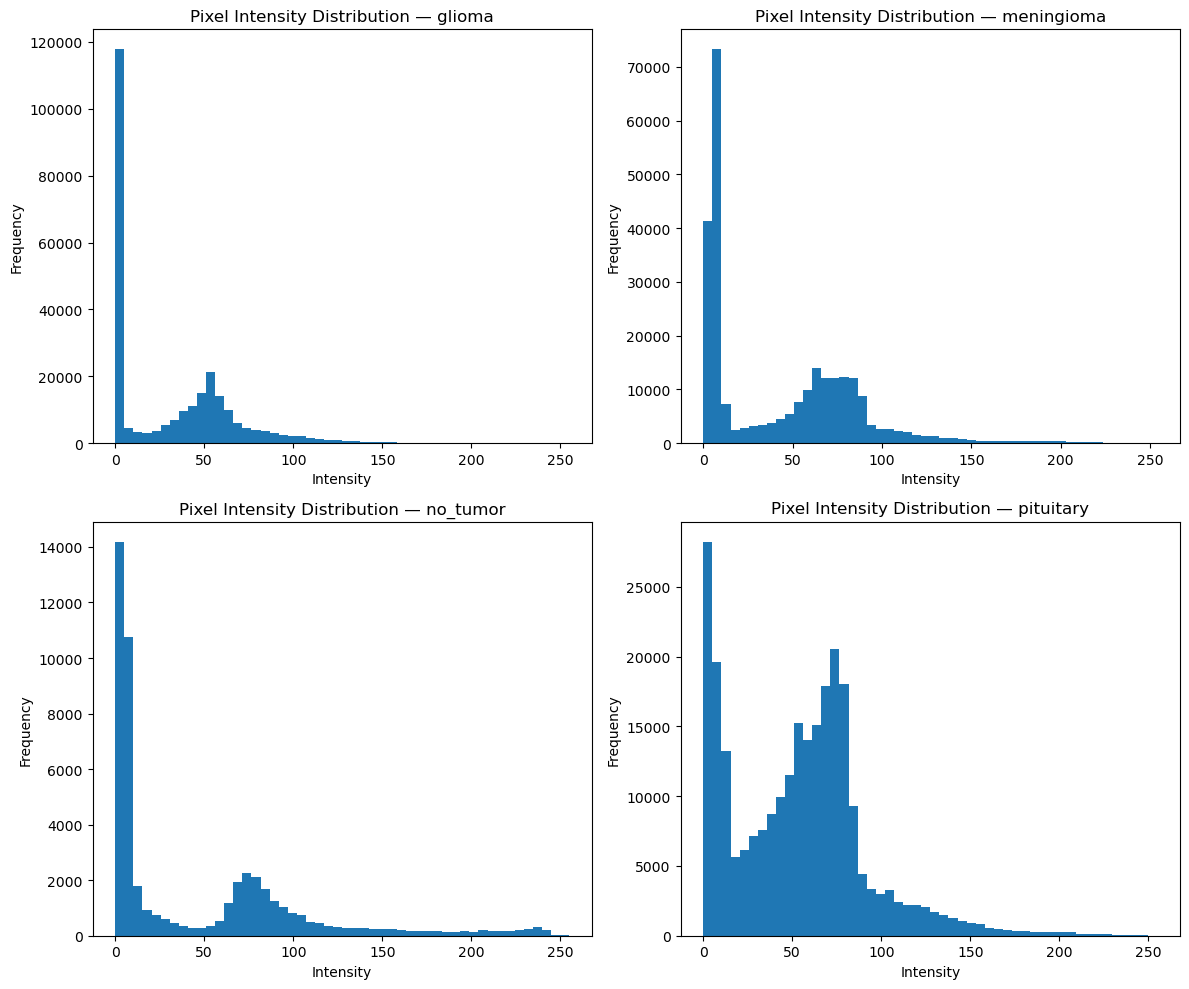

In [15]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.ravel()

for i, cls in enumerate(classes):
    sample_path = df[df["label"] == cls]["image_path"].sample(1).values[0]
    img = Image.open(sample_path).convert("L")
    arr = np.array(img)

    axes[i].hist(arr.flatten(), bins=50)
    axes[i].set_title(f"Pixel Intensity Distribution — {cls}")
    axes[i].set_xlabel("Intensity")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Mean Intensity per Class

In [16]:
mean_intensity = df.groupby("label")["image_path"].apply(
    lambda x: np.mean([np.array(Image.open(i).convert("L")).mean() for i in x.sample(50, random_state=42)])
)

mean_intensity

label
glioma        30.524791
meningioma    44.430031
no_tumor      58.806121
pituitary     49.557815
Name: image_path, dtype: float64

## 13. Mean MRI Representation per Class

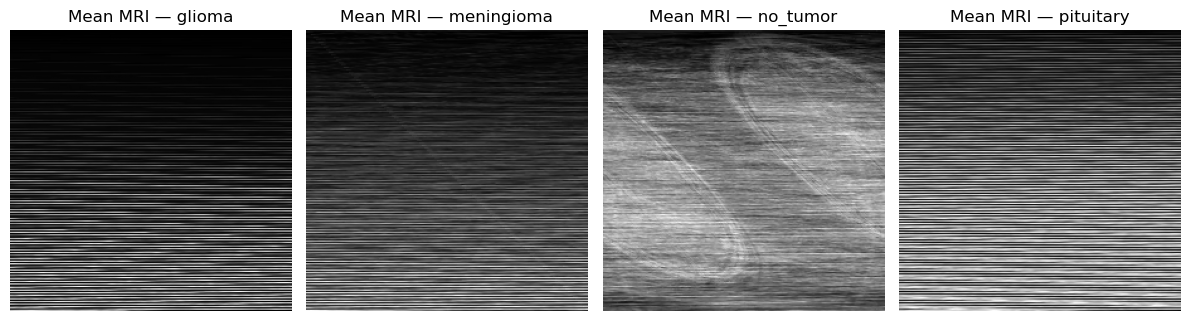

In [17]:
def compute_mean_image(class_name):
    paths = df[df["label"] == class_name]["image_path"].sample(50, random_state=42)

    acc = None

    for p in paths:
        img = np.array(Image.open(p).convert("L"))
        img = np.resize(img, (224,224))

        if acc is None:
            acc = img.astype(np.float32)
        else:
            acc += img

    return acc / len(paths)


plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    plt.subplot(1,4,i+1)
    plt.imshow(compute_mean_image(cls), cmap="gray")
    plt.title(f"Mean MRI — {cls}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Corrupted Image Check

In [19]:
corrupted = []

for path in df["image_path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 14


## 15. Clean Dataset Creation

In [22]:
df_clean = df[~df["image_path"].isin(corrupted)].reset_index(drop=True)
df = df_clean
print("Original:", len(df))
print("Cleaned:", len(df_clean))

Original: 5698
Cleaned: 5698


## 16. Brightness Distribution Analysis

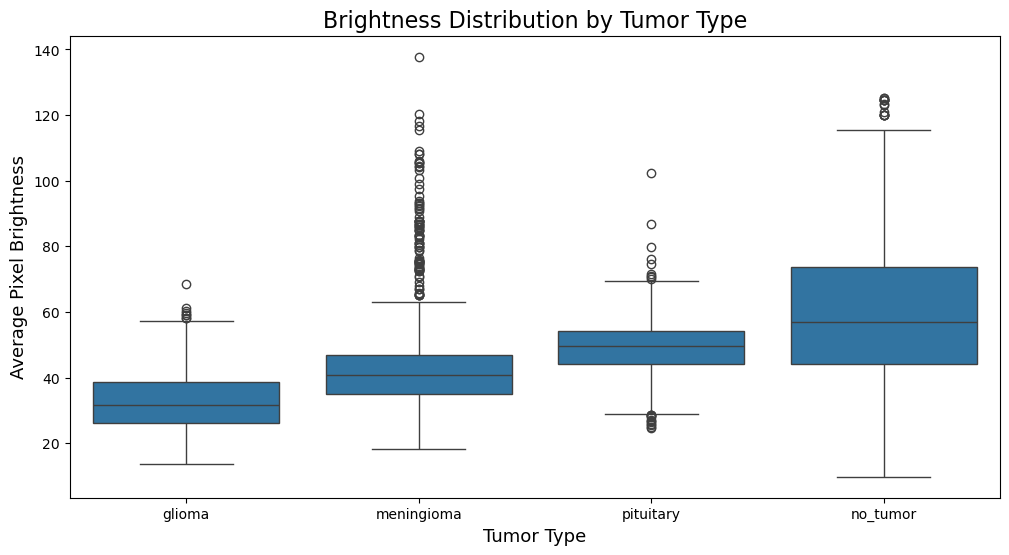

In [23]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["brightness"] = df["image_path"].apply(
    lambda x: np.array(Image.open(x).convert("L")).mean()
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_clean,
    x="label",
    y="brightness"
)

plt.title("Brightness Distribution by Tumor Type", fontsize=16)
plt.xlabel("Tumor Type", fontsize=13)
plt.ylabel("Average Pixel Brightness", fontsize=13)
plt.show()

## 17. Outlier Detection (Brightness-Based)

In [24]:
Q1 = df["brightness"].quantile(0.25)
Q3 = df["brightness"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["brightness"] < Q1 - 1.5*IQR) | (df["brightness"] > Q3 + 1.5*IQR)]

print("Outliers detected:", len(outliers))

Outliers detected: 322


## 18. Final Class Distribution (Cleaned)

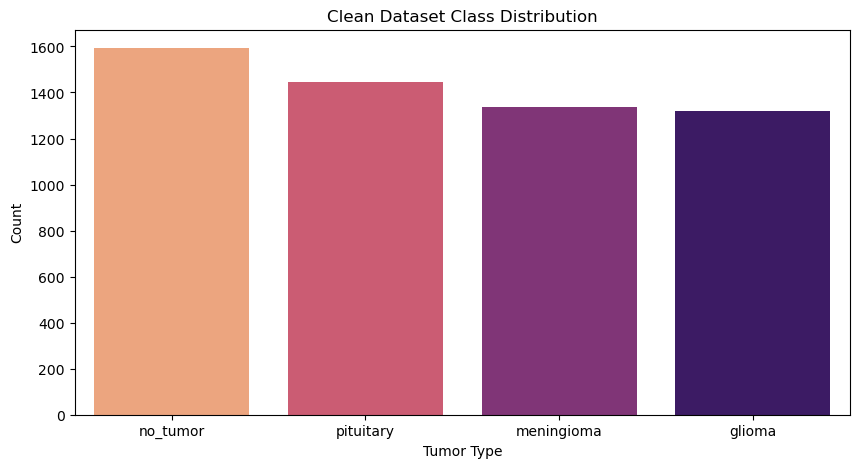

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="label",
    hue="label",
    order=df_clean["label"].value_counts().index,
    palette="magma",
    legend=False
)

plt.title("Clean Dataset Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Count")

plt.show()

## 19. Dataset Quality Summary

In [31]:
summary = {
    "Total Images": len(df_clean),
    "Classes": len(df_clean["label"].unique()),
    "Corrupted Removed": len(df) - len(df_clean),
    "Most Common Class": df_clean["label"].value_counts().idxmax(),
    "Least Common Class": df_clean["label"].value_counts().idxmin()
}

summary

{'Total Images': 5698,
 'Classes': 4,
 'Corrupted Removed': 0,
 'Most Common Class': 'no_tumor',
 'Least Common Class': 'glioma'}

## 20. Image Resolution Distribution

In [35]:
dimensions = []

for path in df_clean["image_path"]:

    img = Image.open(path)

    width, height = img.size

    dimensions.append([width, height])

dim_df = pd.DataFrame(
    dimensions,
    columns=["width", "height"]
)

dim_df.head()

,width,height
0,512,512
1,512,512
2,512,512
3,512,512
4,512,512


## 21. Resolution Scatter Plot

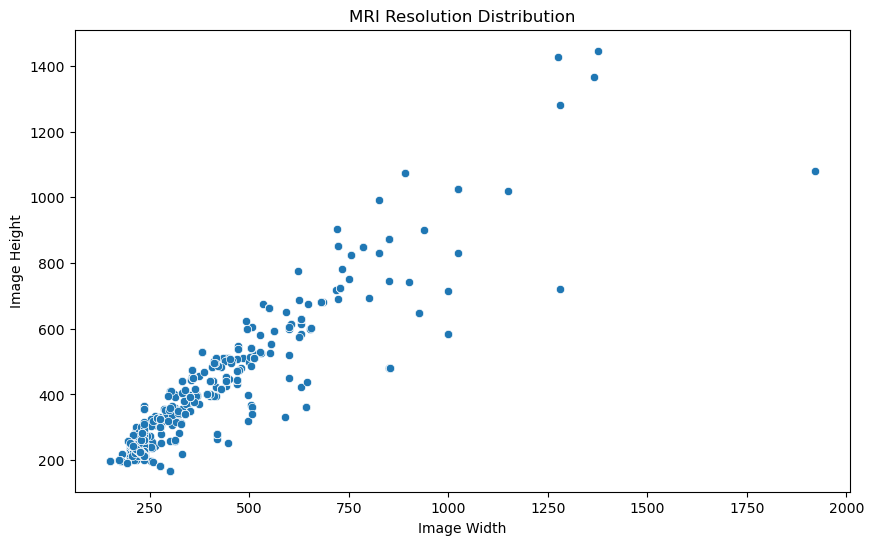

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dim_df,
    x="width",
    y="height"
)

plt.title("MRI Resolution Distribution")
plt.xlabel("Image Width")
plt.ylabel("Image Height")

plt.show()

## 22. Resolution Frequency

In [37]:
dim_df.value_counts().head(10)

width  height
512    512       3955
225    225        268
630    630         76
236    236         53
201    251         43
228    221         38
300    168         38
442    442         37
150    198         36
232    217         35
Name: count, dtype: int64

## 23. RGB Channel Distribution

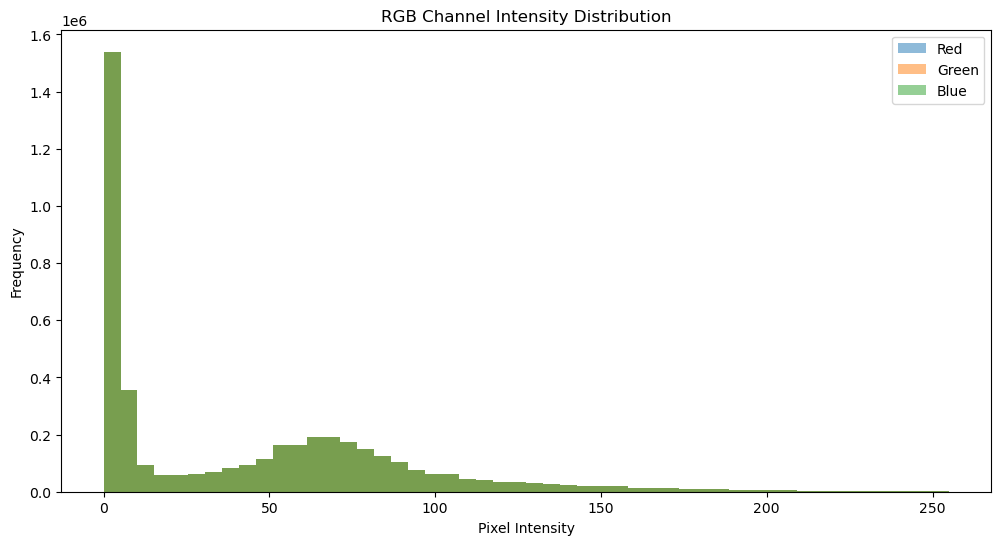

In [38]:
sample_paths = df_clean["image_path"].sample(20, random_state=42)

r_vals = []
g_vals = []
b_vals = []

for path in sample_paths:

    img = Image.open(path).convert("RGB")

    arr = np.array(img)

    r_vals.extend(arr[:,:,0].flatten())
    g_vals.extend(arr[:,:,1].flatten())
    b_vals.extend(arr[:,:,2].flatten())

plt.figure(figsize=(12,6))

plt.hist(r_vals, bins=50, alpha=0.5, label="Red")
plt.hist(g_vals, bins=50, alpha=0.5, label="Green")
plt.hist(b_vals, bins=50, alpha=0.5, label="Blue")

plt.title("RGB Channel Intensity Distribution")

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## 24. MRI Contrast Distribution

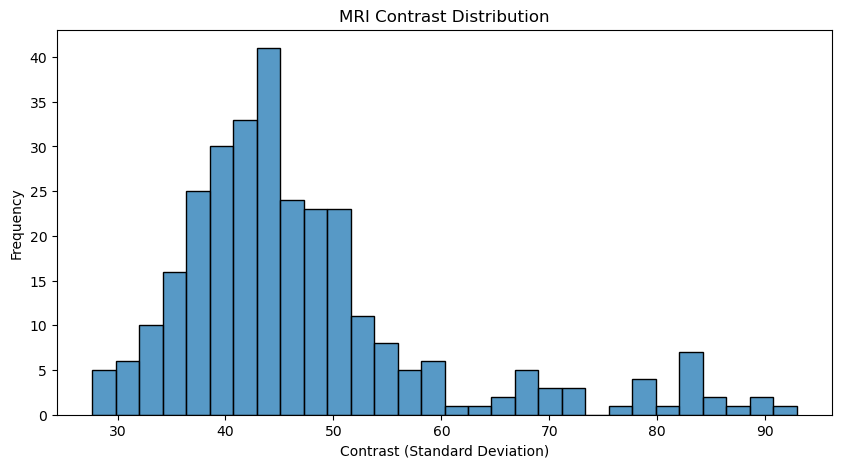

In [39]:
contrast = []

for path in df_clean["image_path"].sample(300, random_state=42):

    img = np.array(
        Image.open(path).convert("L")
    )

    contrast.append(img.std())

plt.figure(figsize=(10,5))

sns.histplot(
    contrast,
    bins=30
)

plt.title("MRI Contrast Distribution")
plt.xlabel("Contrast (Standard Deviation)")
plt.ylabel("Frequency")

plt.show()

## 25. Edge Density Analysis

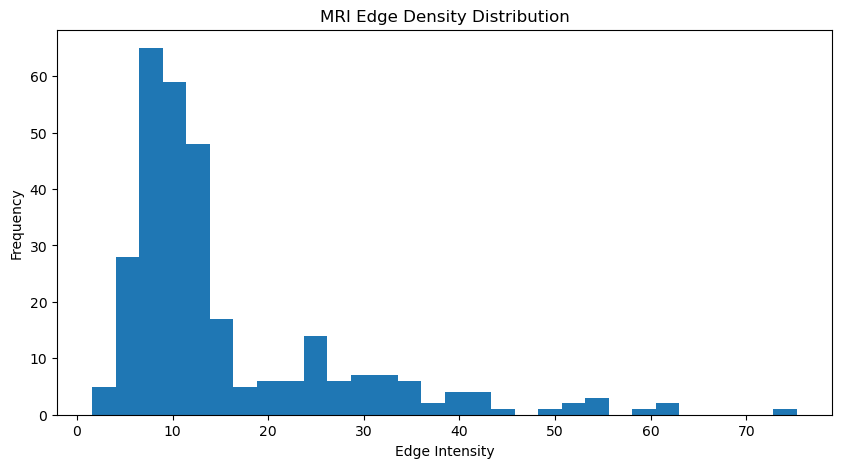

In [40]:
import cv2

edge_density = []

for path in df_clean["image_path"].sample(300, random_state=42):

    img = cv2.imread(path, 0)

    edges = cv2.Canny(img, 100, 200)

    edge_density.append(edges.mean())

plt.figure(figsize=(10,5))

plt.hist(edge_density, bins=30)

plt.title("MRI Edge Density Distribution")
plt.xlabel("Edge Intensity")
plt.ylabel("Frequency")

plt.show()

## 26. Noise Variance Estimation

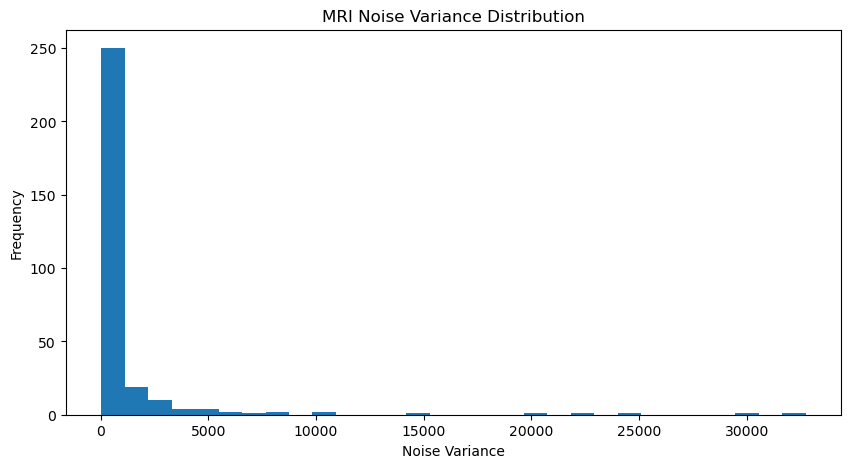

In [41]:
noise_levels = []

for path in df_clean["image_path"].sample(300, random_state=42):

    img = cv2.imread(path, 0)

    noise = cv2.Laplacian(
        img,
        cv2.CV_64F
    ).var()

    noise_levels.append(noise)

plt.figure(figsize=(10,5))

plt.hist(noise_levels, bins=30)

plt.title("MRI Noise Variance Distribution")
plt.xlabel("Noise Variance")
plt.ylabel("Frequency")

plt.show()

## 27. Heatmap Visualization

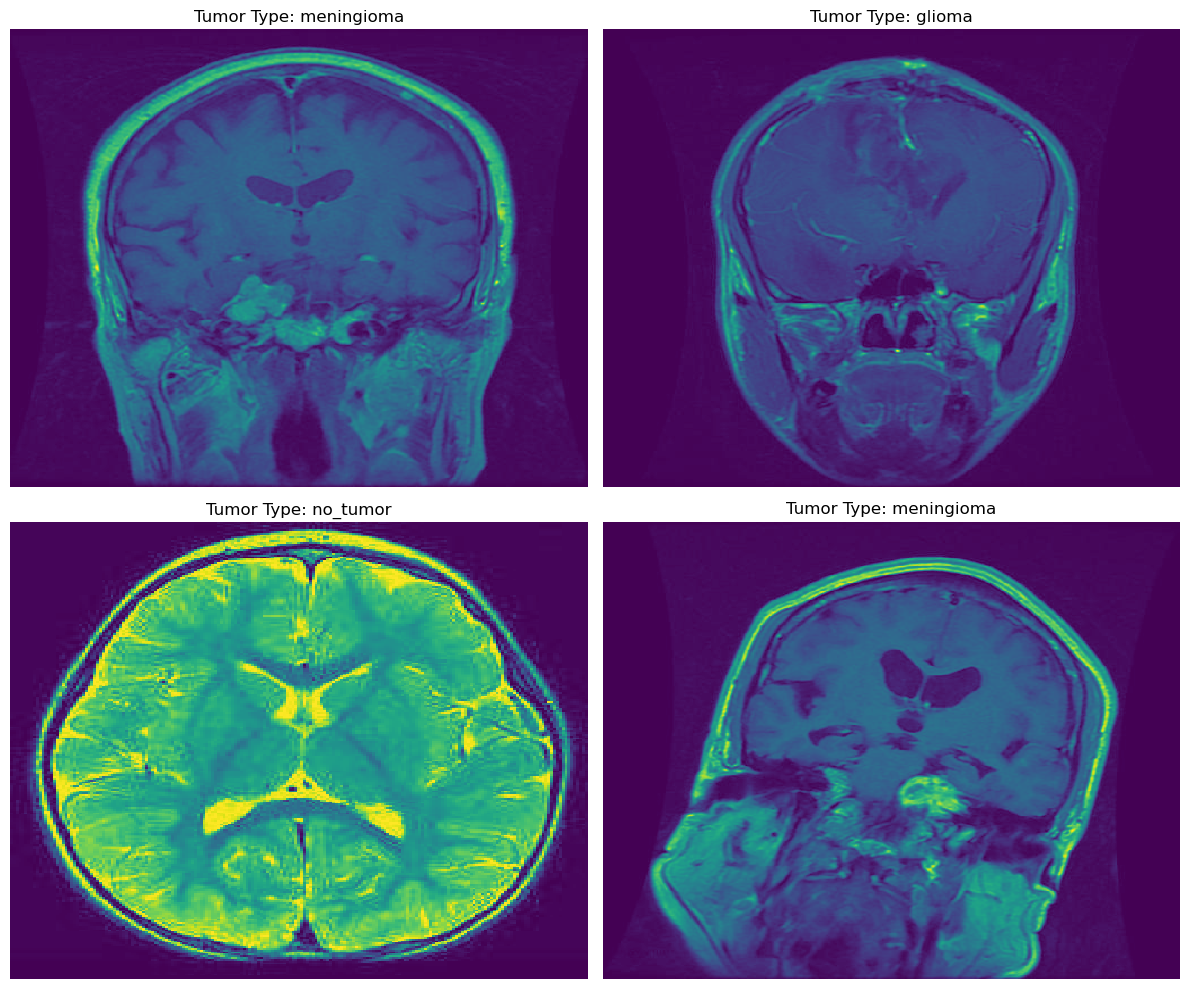

In [42]:
sample_df = df_clean.sample(4, random_state=42)

plt.figure(figsize=(12,10))

for i, row in enumerate(sample_df.itertuples()):

    img = Image.open(row.image_path).convert("L")

    arr = np.array(img)

    plt.subplot(2,2,i+1)

    sns.heatmap(
        arr,
        cmap="viridis",
        cbar=False
    )

    plt.title(f"Tumor Type: {row.label}")

    plt.axis("off")

plt.tight_layout()

plt.show()

## 28. Duplicate MRI Image Detection (Hash-Based)

In [46]:
import hashlib

def get_image_hash(path):

    with open(path, "rb") as f:
        file = f.read()

    return hashlib.md5(file).hexdigest()

df_clean["image_hash"] = df_clean["image_path"].apply(get_image_hash)

print(df_clean["image_hash"].head())

0    4895b73c9642e3a17fb218843ec45983
1    c06c06ed8d82b716da6b9b2c0456bc8d
2    9efb737442ed18655d7e6ab688db26a3
3    6bb273102a035190ad2d96834879ad8f
4    6ed6b88836f0d41c4b62d90b26c151d8
Name: image_hash, dtype: object


## 29. Duplicate Image Analysis

In [47]:
duplicate_images = df_clean[
    df_clean.duplicated(
        subset=["image_hash"],
        keep=False
    )
]

print("Duplicate Images Found:", len(duplicate_images))

Duplicate Images Found: 362


## 30. Visualize Duplicate Entries

In [48]:
duplicate_images[
    ["image_path", "label"]
].head(10)

,image_path,label
1496,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1497,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1532,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1548,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1559,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1570,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1572,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1602,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1687,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma
1937,C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...,meningioma


## 28. Duplicate File Check

In [43]:
duplicates = df_clean.duplicated(
    subset=["image_path"]
).sum()

print("Duplicate File Paths:", duplicates)

Duplicate File Paths: 0


## 29. Missing Value Verification

In [44]:
df_clean.isnull().sum()

image_path    0
label         0
brightness    0
dtype: int64

## 30. Final Dataset Statistics

In [45]:
print("Final Dataset Shape:", df_clean.shape)

print("\nTumor Type Counts:\n")

print(df_clean["label"].value_counts())

print("\nUnique Classes:\n")

print(df_clean["label"].unique())

Final Dataset Shape: (5698, 3)

Tumor Type Counts:

label
no_tumor      1593
pituitary     1445
meningioma    1339
glioma        1321
Name: count, dtype: int64

Unique Classes:

['glioma' 'meningioma' 'pituitary' 'no_tumor']


## Final Dataset Cleaning Report

In [33]:
print("Final Dataset Size:", len(df))

print("\nClass Distribution:")
print(df["label"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Size: 5698

Class Distribution:
label
no_tumor      1593
pituitary     1445
meningioma    1339
glioma        1321
Name: count, dtype: int64

Missing Values:
image_path    0
label         0
brightness    0
dtype: int64

Duplicate Rows:
0
